# Make Figures for second section of Results

"3.2 A multidecadal shift in SAMW volume"

 - Figure 2
 - Supplementary Figures ...

## imports

In [9]:
import sys
import os
import numpy as np
import pandas as pd
import xarray as xr
import dask as da
from dask.diagnostics import ProgressBar
import gsw as gsw

# plotting packages
#import seaborn as sb
#sb.set(style='ticks')
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from matplotlib import colors
import cmocean.cm as cmo
from cmocean.tools import lighten
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.util as cutil

import xesmf as xe 

wrkdir = "/expanse/lustre/projects/ciw112/pbuchanan/JRA55"
os.chdir(wrkdir)

# activate the dask progress bar
ProgressBar().register()

# ignore warnings
import warnings
warnings.filterwarnings("ignore")
os.getcwd()


'/expanse/lustre/projects/ciw112/pbuchanan/JRA55'

## define the grid

In [10]:
%%time

month = np.arange(1,13,1)
year = np.arange(1958.5,2022.51,1)

from datetime import datetime, timedelta
start_date = datetime(1958, 1, 1)
end_date = datetime(2022, 12, 31)
time = pd.date_range(start=start_date, end=end_date, freq="MS") + pd.DateOffset(days=14)

# grab the volume of grid cells on the tracer grid
data = xr.open_dataset('ORCA2.0.full_grid.nc')
lons = data['lon']
lats = data['lat']
lons_bnds = data['bounds_lon']
lats_bnds = data['bounds_lat']



CPU times: user 8.56 ms, sys: 1.95 ms, total: 10.5 ms
Wall time: 10.3 ms


## Load SAMW volumes

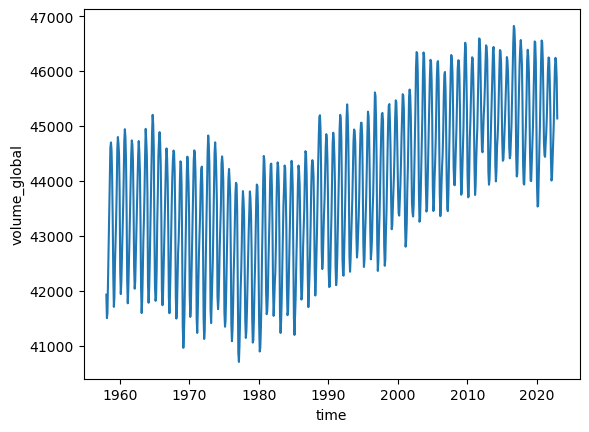

In [11]:

samw_volume_sum = xr.open_dataset("JRA55_pic_1m_SAMWvolumesum_1958-2022.nc")['volume_global']
samw_volume_pac_sum = xr.open_dataset("JRA55_pic_1m_SAMWvolumesum_1958-2022.nc")['volume_pacific']
samw_volume_atl_sum = xr.open_dataset("JRA55_pic_1m_SAMWvolumesum_1958-2022.nc")['volume_atlantic']
samw_volume_ind_sum = xr.open_dataset("JRA55_pic_1m_SAMWvolumesum_1958-2022.nc")['volume_indian']

plt.figure()
samw_volume_sum.plot()


## Load the SAMW array

In [12]:
%%time

samw_cub = xr.open_dataset("JRA55_pic_1m_SAMW_cubic_1958-2022.nc")['so'].squeeze()
samw_cub = samw_cub.stack(time=("year", "month")).drop_vars(['year', 'month']).assign_coords(time=time).chunk({"depth":-1, "y":-1, "x":-1, "time":1})


CPU times: user 9.5 s, sys: 2.94 s, total: 12.4 s
Wall time: 12.5 s


## Regrid the SAMW presence/absence array

In [14]:
%%time

ds_out = xe.util.grid_global(1,1)

# put time on the first dimension
print("transposing")
samw_cub = samw_cub.transpose("time", "depth", "y", "x")
samw_cub = samw_cub.transpose("time", "depth", "y", "x")

# reduce dimensions of datasets to regrid by removing time
print("removing time dimension by averaging")
samw_cub_startARGO = samw_cub.isel(time=slice(564,624)).mean(dim='time')
samw_cub_endARGO = samw_cub.isel(time=slice(-60,780)).mean(dim='time')
samw_cub_start10years = samw_cub.isel(time=slice(0,120)).mean(dim='time')
samw_cub_end10years = samw_cub.isel(time=slice(-120,780)).mean(dim='time')
samw_cub_start20years = samw_cub.isel(time=slice(0,240)).mean(dim='time')
samw_cub_end20years = samw_cub.isel(time=slice(-240,780)).mean(dim='time')
samw_cub_start30years = samw_cub.isel(time=slice(0,360)).mean(dim='time')
samw_cub_end30years = samw_cub.isel(time=slice(-360,780)).mean(dim='time')



transposing
removing time dimension by averaging
CPU times: user 101 ms, sys: 24 ms, total: 125 ms
Wall time: 125 ms


In [17]:
%%time

ds_in = xr.Dataset(
    {'samw_startARGO': ( ('depth', 'y', 'x'), samw_cub_startARGO.values),
     'samw_endARGO': ( ('depth', 'y', 'x'), samw_cub_endARGO.values),
     'samw_start10years': ( ('depth', 'y', 'x'), samw_cub_start10years.values),
     'samw_end10years': ( ('depth', 'y', 'x'), samw_cub_end10years.values),
     'samw_start20years': ( ('depth', 'y', 'x'), samw_cub_start20years.values),
     'samw_end20years': ( ('depth', 'y', 'x'), samw_cub_end20years.values),
     'samw_start30years': ( ('depth', 'y', 'x'), samw_cub_start30years.values),
     'samw_end30years': ( ('depth', 'y', 'x'), samw_cub_end30years.values),
     },
    coords={"lon": (['y','x'], lons.values),
            "lat": (['y','x'], lats.values),
            "depth": (['depth'], samw_cub.coords['depth'].values),
            "time": (['time'], samw_cub.coords['time'].values),
            }
    )
regridder = xe.Regridder(ds_in, ds_out, 'bilinear', ignore_degenerate=True)



[########################################] | 100% Completed | 498.95 ms
[########################################] | 100% Completed | 597.39 ms
[########################################] | 100% Completed | 577.27 ms
[########################################] | 100% Completed | 668.96 ms
[########################################] | 100% Completed | 1.01 sms
[########################################] | 100% Completed | 1.10 s
[########################################] | 100% Completed | 1.01 sms
[########################################] | 100% Completed | 1.09 s
[########################################] | 100% Completed | 1.88 sms
[########################################] | 100% Completed | 1.89 s
[########################################] | 100% Completed | 1.80 sms
[########################################] | 100% Completed | 1.84 s
[########################################] | 100% Completed | 2.72 sms
[########################################] | 100% Completed | 2.80 s
[###########

## Calculate the area of the regular grid

In [21]:
%%time


R = 6_371_000.0  # m

# Extract one-dimensional grid-cell edges as NumPy arrays.
# Using .values prevents xarray coordinate alignment during arithmetic.
lon_edges = ds_out["lon_b"].isel(y_b=0).values
lat_edges = ds_out["lat_b"].isel(x_b=0).values

# Convert edges to radians
lon_edges_rad = np.deg2rad(lon_edges)
lat_edges_rad = np.deg2rad(lat_edges)

# Angular widths
dlon = np.abs(np.diff(lon_edges_rad))  # shape: (360,)
dlat = np.abs(np.diff(lat_edges_rad))  # shape: (180,)

# Cell-centre latitudes
lat_mid_rad = 0.5 * (
    lat_edges_rad[:-1] + lat_edges_rad[1:]
)  # shape: (180,)

# Zonal cell width at cell-centre latitude
dx_values = (R * np.cos(lat_mid_rad[:, None]) * dlon[None, :])  # shape: (180, 360)

# Meridional cell height
dy_values = np.broadcast_to((R * dlat)[:, None], dx_values.shape,).copy()  # shape: (180, 360)

# Exact spherical grid-cell area
area_values = ( R**2 * np.abs(np.sin(lat_edges_rad[1:]) - np.sin(lat_edges_rad[:-1]))[:, None] * dlon[None, :])  # shape: (180, 360)

coords = {
    "lon": ds_out["lon"],
    "lat": ds_out["lat"],
}

dx = xr.DataArray(
    dx_values,
    dims=("y", "x"),
    coords=coords,
    name="dx",
    attrs={
        "long_name": "zonal grid-cell width at cell-centre latitude",
        "units": "m",
    },
)

dy = xr.DataArray(
    dy_values,
    dims=("y", "x"),
    coords=coords,
    name="dy",
    attrs={
        "long_name": "meridional grid-cell height",
        "units": "m",
    },
)

area_reg = xr.DataArray(
    area_values,
    dims=("y", "x"),
    coords=coords,
    name="area",
    attrs={
        "long_name": "horizontal grid-cell area",
        "units": "m2",
    },
)

ds_out["dx"] = dx
ds_out["dy"] = dy
ds_out["cell_area"] = area_reg


CPU times: user 2.96 ms, sys: 53 μs, total: 3.01 ms
Wall time: 2.54 ms


In [23]:
%%time

print("Regridding")

samw_startARGO_reg = regridder(ds_in['samw_startARGO'])
samw_endARGO_reg = regridder(ds_in['samw_endARGO'])
samw_start10_reg = regridder(ds_in['samw_start10years'])
samw_end10_reg = regridder(ds_in['samw_end10years'])
samw_start20_reg = regridder(ds_in['samw_start20years'])
samw_end20_reg = regridder(ds_in['samw_end20years'])
samw_start30_reg = regridder(ds_in['samw_start30years'])
samw_end30_reg = regridder(ds_in['samw_end30years'])

samw_end30_reg

Regridding
CPU times: user 1.01 s, sys: 47.8 ms, total: 1.05 s
Wall time: 1.09 s


<xarray.DataArray (depth: 100, y: 180, x: 360)> Size: 52MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])
Coordinates:
  * depth    (depth) int64 800B 5 25 45 65 85 105 ... 1905 1925 1945 1965 1985
    lon      (y, x) float64 518kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
    lat      (y, x) float64 518kB -89.5 -89.5 -89.5 -89.5 ... 89.5 89.5 89.5
Dimensions without coordinates: y, x
Attributes:
    regrid_method:  bilinear

In [26]:
%%time

depths = samw_cub.coords['depth']
depth_thicknesses = np.diff(depths)
depth_thicknesses = np.insert(depth_thicknesses, 0, 15)

depth_thicknesses = xr.DataArray(
    depth_thicknesses,
    dims=["depth"],
    coords={"depth": depths}
    )

depth_thicknesses

CPU times: user 696 μs, sys: 0 ns, total: 696 μs
Wall time: 679 μs


<xarray.DataArray (depth: 100)> Size: 800B
array([15, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20])
Coordinates:
  * depth    (depth) int64 800B 5 25 45 65 85 105 ... 1905 1925 1945 1965 1985

In [27]:
%%time

# Calculate vertical thickness
samw_thick_startARGO_reg = (samw_startARGO_reg * depth_thicknesses).sum(dim='depth')
samw_thick_endARGO_reg = (samw_endARGO_reg * depth_thicknesses).sum(dim='depth')
samw_thick_start10_reg = (samw_start10_reg * depth_thicknesses).sum(dim='depth')
samw_thick_end10_reg = (samw_end10_reg * depth_thicknesses).sum(dim='depth')
samw_thick_start20_reg = (samw_start20_reg * depth_thicknesses).sum(dim='depth')
samw_thick_end20_reg = (samw_end20_reg * depth_thicknesses).sum(dim='depth')
samw_thick_start30_reg = (samw_start30_reg * depth_thicknesses).sum(dim='depth')
samw_thick_end30_reg = (samw_end30_reg * depth_thicknesses).sum(dim='depth')

# Calculate zonal thickness
samw_side_startARGO_reg = (samw_startARGO_reg * dx)
samw_side_endARGO_reg = (samw_endARGO_reg * dx)
samw_side_start10_reg = (samw_start10_reg * dx)
samw_side_end10_reg = (samw_end10_reg * dx)
samw_side_start20_reg = (samw_start20_reg * dx)
samw_side_end20_reg = (samw_end20_reg * dx)
samw_side_start30_reg = (samw_start30_reg * dx)
samw_side_end30_reg = (samw_end30_reg * dx)

# separate into basins
lons_tmp = samw_startARGO_reg.coords['lon']
lons_tmp = lons_tmp.where(lons_tmp >0.0, other=lons_tmp+360.0)
tmp = samw_side_startARGO_reg.assign_coords({"lon":lons_tmp})
samw_pacside_startARGO_reg = tmp.where(tmp.coords['lon'] > 140.0, other=0.0).where(tmp.coords['lon'] < 270.0, other=0.0).sum(dim='x')
tmp = samw_side_endARGO_reg.assign_coords({"lon":lons_tmp})
samw_pacside_endARGO_reg = tmp.where(tmp.coords['lon'] > 140.0, other=0.0).where(tmp.coords['lon'] < 270.0, other=0.0).sum(dim='x')
samw_atlside_startARGO_reg = samw_side_startARGO_reg.isel(x=slice(110,200)).sum(dim='x')
samw_atlside_endARGO_reg = samw_side_endARGO_reg.isel(x=slice(110,200)).sum(dim='x')
samw_indside_startARGO_reg = samw_side_startARGO_reg.isel(x=slice(200,320)).sum(dim='x')
samw_indside_endARGO_reg = samw_side_endARGO_reg.isel(x=slice(200,320)).sum(dim='x')

lons_tmp = samw_start10_reg.coords['lon']
lons_tmp = lons_tmp.where(lons_tmp >0.0, other=lons_tmp+360.0)
tmp = samw_side_start10_reg.assign_coords({"lon":lons_tmp})
samw_pacside_start10_reg = tmp.where(tmp.coords['lon'] > 140.0, other=0.0).where(tmp.coords['lon'] < 270.0, other=0.0).sum(dim='x')
tmp = samw_side_end10_reg.assign_coords({"lon":lons_tmp})
samw_pacside_end10_reg = tmp.where(tmp.coords['lon'] > 140.0, other=0.0).where(tmp.coords['lon'] < 270.0, other=0.0).sum(dim='x')
samw_atlside_start10_reg = samw_side_start10_reg.isel(x=slice(110,200)).sum(dim='x')
samw_atlside_end10_reg = samw_side_end10_reg.isel(x=slice(110,200)).sum(dim='x')
samw_indside_start10_reg = samw_side_start10_reg.isel(x=slice(200,320)).sum(dim='x')
samw_indside_end10_reg = samw_side_end10_reg.isel(x=slice(200,320)).sum(dim='x')

lons_tmp = samw_start20_reg.coords['lon']
lons_tmp = lons_tmp.where(lons_tmp >0.0, other=lons_tmp+360.0)
tmp = samw_side_start20_reg.assign_coords({"lon":lons_tmp})
samw_pacside_start20_reg = tmp.where(tmp.coords['lon'] > 140.0, other=0.0).where(tmp.coords['lon'] < 270.0, other=0.0).sum(dim='x')
tmp = samw_side_end20_reg.assign_coords({"lon":lons_tmp})
samw_pacside_end20_reg = tmp.where(tmp.coords['lon'] > 140.0, other=0.0).where(tmp.coords['lon'] < 270.0, other=0.0).sum(dim='x')
samw_atlside_start20_reg = samw_side_start20_reg.isel(x=slice(110,200)).sum(dim='x')
samw_atlside_end20_reg = samw_side_end20_reg.isel(x=slice(110,200)).sum(dim='x')
samw_indside_start20_reg = samw_side_start20_reg.isel(x=slice(200,320)).sum(dim='x')
samw_indside_end20_reg = samw_side_end20_reg.isel(x=slice(200,320)).sum(dim='x')

lons_tmp = samw_start30_reg.coords['lon']
lons_tmp = lons_tmp.where(lons_tmp >0.0, other=lons_tmp+360.0)
tmp = samw_side_start30_reg.assign_coords({"lon":lons_tmp})
samw_pacside_start30_reg = tmp.where(tmp.coords['lon'] > 140.0, other=0.0).where(tmp.coords['lon'] < 270.0, other=0.0).sum(dim='x')
tmp = samw_side_end30_reg.assign_coords({"lon":lons_tmp})
samw_pacside_end30_reg = tmp.where(tmp.coords['lon'] > 140.0, other=0.0).where(tmp.coords['lon'] < 270.0, other=0.0).sum(dim='x')
samw_atlside_start30_reg = samw_side_start20_reg.isel(x=slice(110,200)).sum(dim='x')
samw_atlside_end30_reg = samw_side_end20_reg.isel(x=slice(110,200)).sum(dim='x')
samw_indside_start30_reg = samw_side_start20_reg.isel(x=slice(200,320)).sum(dim='x')
samw_indside_end30_reg = samw_side_end20_reg.isel(x=slice(200,320)).sum(dim='x')


CPU times: user 637 ms, sys: 245 ms, total: 882 ms
Wall time: 884 ms


In [28]:
%%time

### wrap the longitudes for the top-down vertical thicknesses
samw_thick_startARGO_reg = xr.DataArray(
    samw_thick_startARGO_reg,
    dims=("y", "x"),
    coords={"lon": (['x'], ds_out.coords['lon'].isel(y=0).values),
            "lat": (['y'], ds_out.coords['lat'].isel(x=0).values),
            }
    )
samw_thick_endARGO_reg = xr.DataArray(
    samw_thick_endARGO_reg,
    dims=("y", "x"),
    coords={"lon": (['x'], ds_out.coords['lon'].isel(y=0).values),
            "lat": (['y'], ds_out.coords['lat'].isel(x=0).values),
            }
    )
samw_thick_start10_reg = xr.DataArray(
    samw_thick_start10_reg,
    dims=("y", "x"),
    coords={"lon": (['x'], ds_out.coords['lon'].isel(y=0).values),
            "lat": (['y'], ds_out.coords['lat'].isel(x=0).values),
            }
    )
samw_thick_end10_reg = xr.DataArray(
    samw_thick_end10_reg,
    dims=("y", "x"),
    coords={"lon": (['x'], ds_out.coords['lon'].isel(y=0).values),
            "lat": (['y'], ds_out.coords['lat'].isel(x=0).values),
            }
    )
samw_thick_start20_reg = xr.DataArray(
    samw_thick_start20_reg,
    dims=("y", "x"),
    coords={"lon": (['x'], ds_out.coords['lon'].isel(y=0).values),
            "lat": (['y'], ds_out.coords['lat'].isel(x=0).values),
            }
    )
samw_thick_end20_reg = xr.DataArray(
    samw_thick_end20_reg,
    dims=("y", "x"),
    coords={"lon": (['x'], ds_out.coords['lon'].isel(y=0).values),
            "lat": (['y'], ds_out.coords['lat'].isel(x=0).values),
            }
    )
samw_thick_start30_reg = xr.DataArray(
    samw_thick_start30_reg,
    dims=("y", "x"),
    coords={"lon": (['x'], ds_out.coords['lon'].isel(y=0).values),
            "lat": (['y'], ds_out.coords['lat'].isel(x=0).values),
            }
    )
samw_thick_end30_reg = xr.DataArray(
    samw_thick_end30_reg,
    dims=("y", "x"),
    coords={"lon": (['x'], ds_out.coords['lon'].isel(y=0).values),
            "lat": (['y'], ds_out.coords['lat'].isel(x=0).values),
            }
    )

samw_thick_startARGO_reg_wrapped, lon_reg_wrapped = cutil.add_cyclic_point(samw_thick_startARGO_reg, coord=samw_thick_startARGO_reg.coords['lon'])
samw_thick_endARGO_reg_wrapped, lon_reg_wrapped = cutil.add_cyclic_point(samw_thick_endARGO_reg, coord=samw_thick_endARGO_reg.coords['lon'])
samw_thick_start10_reg_wrapped, lon_reg_wrapped = cutil.add_cyclic_point(samw_thick_start10_reg, coord=samw_thick_start10_reg.coords['lon'])
samw_thick_end10_reg_wrapped, lon_reg_wrapped = cutil.add_cyclic_point(samw_thick_end10_reg, coord=samw_thick_end10_reg.coords['lon'])
samw_thick_start20_reg_wrapped, lon_reg_wrapped = cutil.add_cyclic_point(samw_thick_start20_reg, coord=samw_thick_start20_reg.coords['lon'])
samw_thick_end20_reg_wrapped, lon_reg_wrapped = cutil.add_cyclic_point(samw_thick_end20_reg, coord=samw_thick_end20_reg.coords['lon'])
samw_thick_start30_reg_wrapped, lon_reg_wrapped = cutil.add_cyclic_point(samw_thick_start30_reg, coord=samw_thick_start30_reg.coords['lon'])
samw_thick_end30_reg_wrapped, lon_reg_wrapped = cutil.add_cyclic_point(samw_thick_end30_reg, coord=samw_thick_end30_reg.coords['lon'])




CPU times: user 6.34 ms, sys: 809 μs, total: 7.14 ms
Wall time: 6.78 ms


## Figure 2

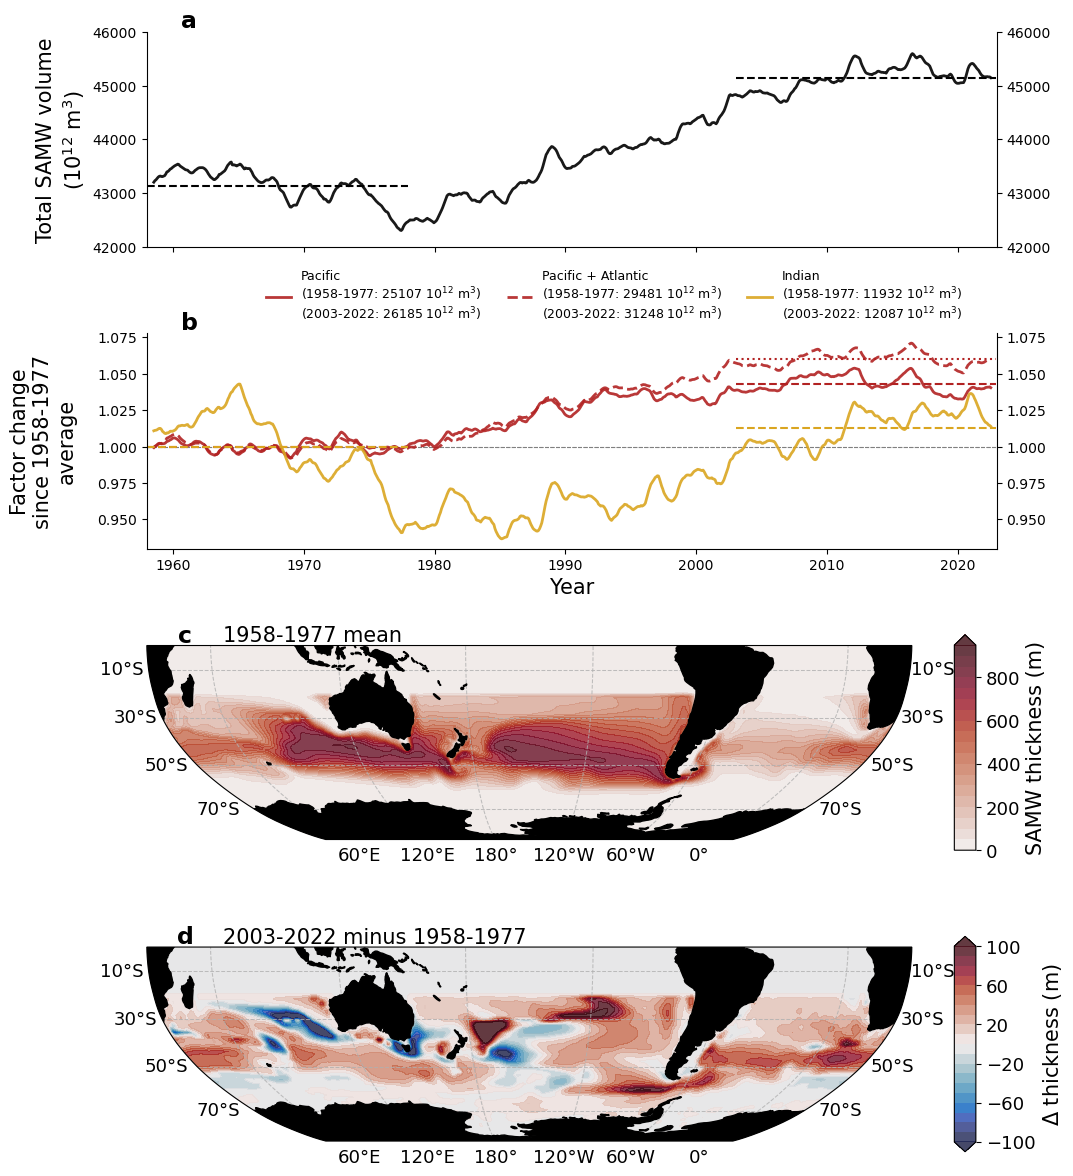

In [29]:

proj = ccrs.Robinson(central_longitude=210)

levs1 = np.arange(0,81,8)
levs2 = np.arange(-10,11,1)
levs9 = np.arange(0,21,2)
levs10 = np.arange(-5,5.1,0.5)

colmap1 = lighten(cmo.amp, 0.8)
colmap2 = lighten(cmo.balance, 0.8)
fstic = 13
fslab = 15

fig = plt.figure(figsize=(10,14), facecolor='w')
gs = GridSpec(4,1)

ax7 = plt.subplot(gs[0,0])
ax8 = plt.subplot(gs[1,0])
ax9 = plt.subplot(gs[2,0], projection=proj)
ax10 = plt.subplot(gs[3,0], projection=proj)

ax9.add_feature(cfeature.LAND, zorder=3, color='k')
ax10.add_feature(cfeature.LAND, zorder=3, color='k')
ax9.set_extent([-180,180,-90,0], crs=ccrs.PlateCarree())
ax10.set_extent([-180,180,-90,0], crs=ccrs.PlateCarree())

ax7.tick_params(right=True, labelbottom=False, labelright=True)
ax8.tick_params(right=True, labelright=True)

ax7.spines[['top']].set_visible(False)
ax8.spines[['top']].set_visible(False)

depths = depth_thicknesses.coords['depth']
lats_reg = ds_out['lat'].isel(x=0)

lwid = [1.0, 2.0, 2.0, 2.0]
cols = ['k', 'k']
lsty = ['-', '-']
alfs = 0.9

#ax7.plot(time, samw_volume_sum, color=cols[0], linewidth=lwid[0], alpha=alfs, linestyle=lsty[0])
ax7.plot(time, samw_volume_sum.rolling(time=12, center=True).mean(), color=cols[1], linewidth=lwid[1], alpha=alfs, linestyle=lsty[1])
ax7.plot(time[0:240], np.ones((240))*samw_volume_sum.isel(time=slice(0,240)).mean(dim='time').values, 'k--')
ax7.plot(time[-240::], np.ones((240))*samw_volume_sum.isel(time=slice(-240,780)).mean(dim='time').values, 'k--')

samw_volume_pac_per = (samw_volume_pac_sum / samw_volume_pac_sum.isel(time=slice(0,240)).mean(dim="time"))
samw_volume_ind_per = (samw_volume_ind_sum / samw_volume_ind_sum.isel(time=slice(0,240)).mean(dim="time"))
samw_volume_pacatl_per = ((samw_volume_atl_sum + samw_volume_pac_sum) / (samw_volume_atl_sum + samw_volume_pac_sum).isel(time=slice(0,240)).mean(dim="time"))


cols = ['firebrick', 'goldenrod', 'royalblue']
lab = ['Pacific\n(1958-1977: %d 10$^{12}$ m$^{3}$)\n(2003-2022: %d 10$^{12}$ m$^{3}$)'%(samw_volume_pac_sum.isel(time=slice(0,240)).mean(dim='time'), samw_volume_pac_sum.isel(time=slice(-240,-1)).mean(dim='time')), \
       'Indian\n(1958-1977: %d 10$^{12}$ m$^{3}$)\n(2003-2022: %d 10$^{12}$ m$^{3}$)'%(samw_volume_ind_sum.isel(time=slice(0,240)).mean(dim='time'), samw_volume_ind_sum.isel(time=slice(-240,-1)).mean(dim='time')), \
       'Pacific + Atlantic\n(1958-1977: %d 10$^{12}$ m$^{3}$)\n(2003-2022: %d 10$^{12}$ m$^{3}$)'%((samw_volume_atl_sum + samw_volume_pac_sum).isel(time=slice(0,240)).mean(dim='time'), (samw_volume_atl_sum + samw_volume_pac_sum).isel(time=slice(-240,-1)).mean(dim='time'))]

#ax8.plot(time, samw_volume_pac_per, color=cols[0], linewidth=lwid[0], alpha=alfs, linestyle=lsty[0])
#ax8.plot(time, samw_volume_pacatl_per, color=cols[0], linewidth=lwid[0], alpha=alfs, linestyle="--")
#ax8.plot(time, samw_volume_ind_per, color=cols[1], linewidth=lwid[0], alpha=alfs, linestyle=lsty[0])

ax8.plot(time, np.ones(len(time))*samw_volume_pac_per.isel(time=slice(0,240)).mean(dim='time').values, color='grey', linewidth=0.75, alpha=1.0, linestyle='--')
ax8.plot(time, np.ones(len(time))*samw_volume_pacatl_per.isel(time=slice(0,240)).mean(dim='time').values, color='grey', linewidth=0.75, alpha=1.0, linestyle='--')
ax8.plot(time, np.ones(len(time))*samw_volume_ind_per.isel(time=slice(0,240)).mean(dim='time').values, color='grey', linewidth=0.75, alpha=1.0, linestyle='--')

ax8.plot(time, samw_volume_pac_per.rolling(time=12, center=True).mean(), color=cols[0], linewidth=lwid[1], alpha=alfs, linestyle=lsty[1], label=lab[0])
ax8.plot(time, samw_volume_pacatl_per.rolling(time=12, center=True).mean(), color=cols[0], linewidth=lwid[1], alpha=alfs, linestyle="--", label=lab[2])
ax8.plot(time, samw_volume_ind_per.rolling(time=12, center=True).mean(), color=cols[1], linewidth=lwid[1], alpha=alfs, linestyle=lsty[1], label=lab[1])

ax8.plot(time[0:240], np.ones((240))*samw_volume_pac_per.isel(time=slice(0,240)).mean(dim='time').values, linestyle='--', color=cols[0])
ax8.plot(time[-240::], np.ones((240))*samw_volume_pac_per.isel(time=slice(-240,780)).mean(dim='time').values, linestyle='--', color=cols[0])
ax8.plot(time[0:240], np.ones((240))*samw_volume_ind_per.isel(time=slice(0,240)).mean(dim='time').values, linestyle='--', color=cols[1])
ax8.plot(time[-240::], np.ones((240))*samw_volume_ind_per.isel(time=slice(-240,780)).mean(dim='time').values, linestyle='--', color=cols[1])
ax8.plot(time[-240::], np.ones((240))*samw_volume_pacatl_per.isel(time=slice(-240,780)).mean(dim='time').values, linestyle=':', color=cols[0])

levs9 = np.arange(0,1000,50)
levs10 = np.arange(-100,101,10)

p9 = ax9.contourf(lon_reg_wrapped, ds_out['lat'].isel(x=0), samw_thick_start20_reg_wrapped, transform=ccrs.PlateCarree(), levels=levs9, cmap=colmap1, vmin=np.min(levs9), vmax=np.max(levs9), extend='max')
p10 = ax10.contourf(lon_reg_wrapped, ds_out['lat'].isel(x=0), (samw_thick_end20_reg_wrapped - samw_thick_start20_reg_wrapped), transform=ccrs.PlateCarree(), levels=levs10, cmap=colmap2, vmin=np.min(levs10), vmax=np.max(levs10), extend='both')

ax7.set_xlim(start_date,end_date)
ax8.set_xlim(start_date,end_date)
ax7.set_ylim(42000,46000)

ax8.set_xlabel("Year", fontsize=fslab)
ax7.set_ylabel("Total SAMW volume\n(10$^{12}$ m$^{3}$)", fontsize=fslab)
ax8.set_ylabel("Factor change\nsince 1958-1977\naverage", fontsize=fslab, labelpad=15)
ax8.legend(loc='upper center', frameon=False, fontsize=fstic-4, ncol=3, bbox_to_anchor=(0.55,1.35))

cbar9 = plt.colorbar(p9, ax=ax9, orientation='vertical', ticks=levs9[::4], fraction=0.05, aspect=10, pad=0.05)
cbar10 = plt.colorbar(p10, ax=ax10, orientation='vertical', ticks=levs10[::4], fraction=0.05, aspect=10, pad=0.05)
cbar9.ax.set_ylabel("SAMW thickness (m)", fontsize=fslab)
cbar10.ax.set_ylabel("$\Delta$ thickness (m)", fontsize=fslab)
cbar9.ax.tick_params(labelsize=fstic)
cbar10.ax.tick_params(labelsize=fstic)

plt.subplots_adjust(left=0.05, top=0.9, bottom=0.1, hspace=0.4)


xx = 0.05; yy = 1.05
plt.text(xx,yy,'a', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax7.transAxes)
plt.text(xx,yy,'b', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax8.transAxes)
plt.text(xx,yy,'c', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax9.transAxes)
plt.text(xx,yy,'d', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax10.transAxes)

xx = 0.05; yy = 1.05
plt.text(xx*2,yy,"1958-1977 mean", fontsize=fslab, va='center', ha='left', transform=ax9.transAxes)
plt.text(xx*2,yy,"2003-2022 minus 1958-1977", fontsize=fslab, va='center', ha='left', transform=ax10.transAxes)


import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

for ax in [ax9, ax10]:
    gl = ax.gridlines(
         crs=ccrs.PlateCarree(),
         draw_labels=True,
         linewidth=0.75,
         linestyle="--",
         alpha=0.8,
         x_inline=False,
         y_inline=False,
    )

    gl.xlocator = mticker.FixedLocator(
        [-180, -120, -60, 0, 60, 120]
    )
    gl.ylocator = mticker.FixedLocator(
        [-70, -50, -30, -10]
    )

    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()

    gl.top_labels = False
    gl.right_labels = True
    gl.left_labels = True
    gl.bottom_labels = True

    gl.xlabel_style = {"size": fstic}
    gl.ylabel_style = {"size": fstic}


In [37]:
fig.savefig('/home/pbuchanan/analysis_samw/fig-samw_cub_change_20years.png', dpi=300, bbox_inches='tight')
fig.savefig('/home/pbuchanan/analysis_samw/fig-samw_cub_change_20years.pdf', dpi=300, bbox_inches='tight')
fig.savefig('/home/pbuchanan/analysis_samw/fig-samw_cub_change_20years_trans.png', dpi=300, bbox_inches='tight', transparent=True)


### check first and last 10 years, not 20 years

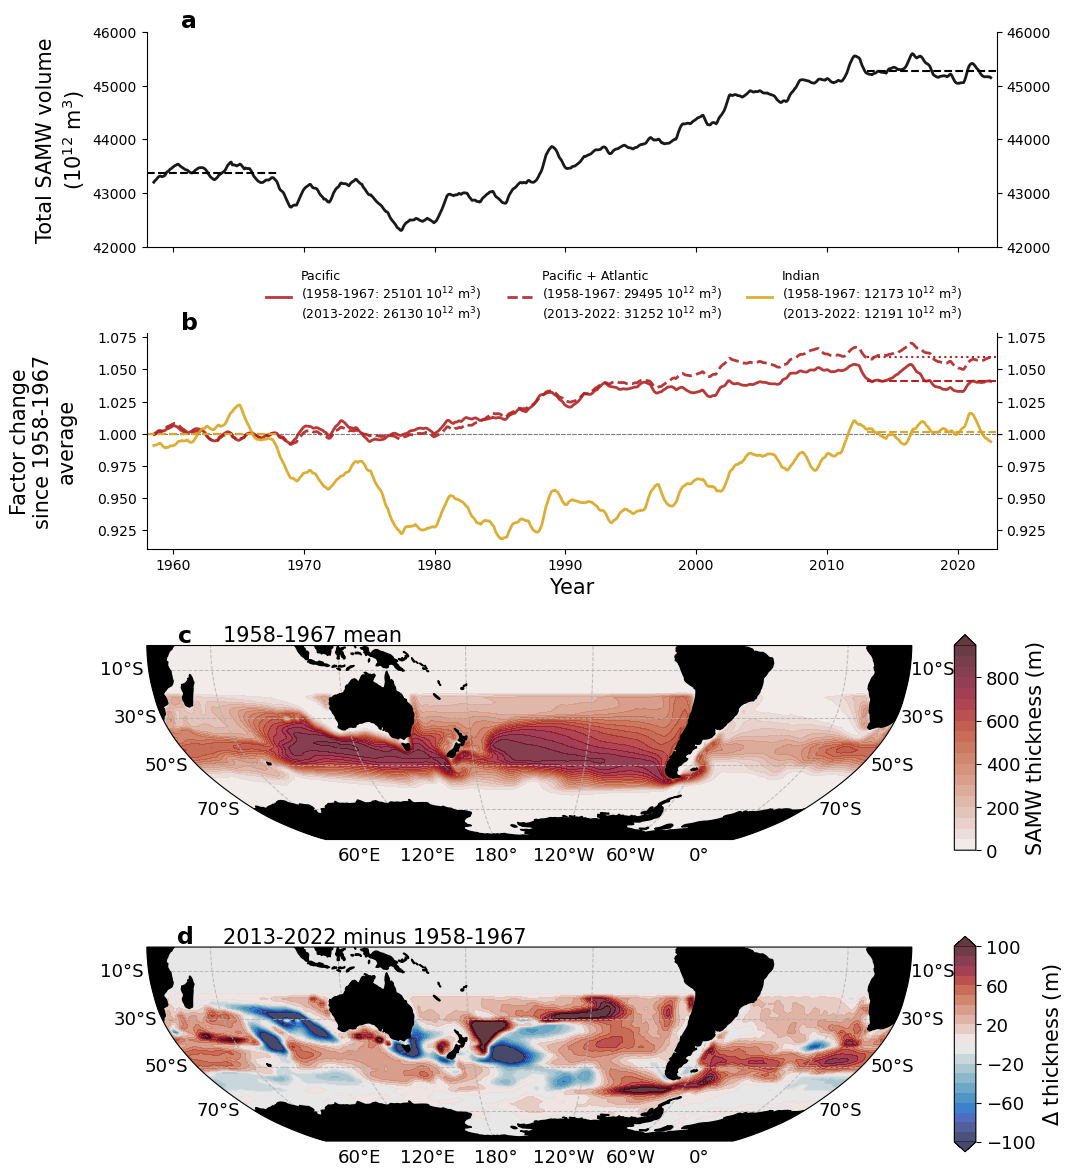

In [30]:

proj = ccrs.Robinson(central_longitude=210)

levs1 = np.arange(0,81,8)
levs2 = np.arange(-10,11,1)
levs9 = np.arange(0,21,2)
levs10 = np.arange(-5,5.1,0.5)

colmap1 = lighten(cmo.amp, 0.8)
colmap2 = lighten(cmo.balance, 0.8)
fstic = 13
fslab = 15

fig = plt.figure(figsize=(10,14), facecolor='w')
gs = GridSpec(4,1)

ax7 = plt.subplot(gs[0,0])
ax8 = plt.subplot(gs[1,0])
ax9 = plt.subplot(gs[2,0], projection=proj)
ax10 = plt.subplot(gs[3,0], projection=proj)

ax9.add_feature(cfeature.LAND, zorder=3, color='k')
ax10.add_feature(cfeature.LAND, zorder=3, color='k')
ax9.set_extent([-180,180,-90,0], crs=ccrs.PlateCarree())
ax10.set_extent([-180,180,-90,0], crs=ccrs.PlateCarree())

ax7.tick_params(right=True, labelbottom=False, labelright=True)
ax8.tick_params(right=True, labelright=True)

ax7.spines[['top']].set_visible(False)
ax8.spines[['top']].set_visible(False)

depths = depth_thicknesses.coords['depth']
lats_reg = ds_out['lat'].isel(x=0)

lwid = [1.0, 2.0, 2.0, 2.0]
cols = ['k', 'k']
lsty = ['-', '-']
alfs = 0.9

#ax7.plot(time, samw_volume_sum, color=cols[0], linewidth=lwid[0], alpha=alfs, linestyle=lsty[0])
ax7.plot(time, samw_volume_sum.rolling(time=12, center=True).mean(), color=cols[1], linewidth=lwid[1], alpha=alfs, linestyle=lsty[1])
ax7.plot(time[0:120], np.ones((120))*samw_volume_sum.isel(time=slice(0,120)).mean(dim='time').values, 'k--')
ax7.plot(time[-120::], np.ones((120))*samw_volume_sum.isel(time=slice(-120,780)).mean(dim='time').values, 'k--')

samw_volume_pac_per = (samw_volume_pac_sum / samw_volume_pac_sum.isel(time=slice(0,120)).mean(dim="time"))
samw_volume_ind_per = (samw_volume_ind_sum / samw_volume_ind_sum.isel(time=slice(0,120)).mean(dim="time"))
samw_volume_pacatl_per = ((samw_volume_atl_sum + samw_volume_pac_sum) / (samw_volume_atl_sum + samw_volume_pac_sum).isel(time=slice(0,120)).mean(dim="time"))


cols = ['firebrick', 'goldenrod', 'royalblue']
lab = ['Pacific\n(1958-1967: %d 10$^{12}$ m$^{3}$)\n(2013-2022: %d 10$^{12}$ m$^{3}$)'%(samw_volume_pac_sum.isel(time=slice(0,120)).mean(dim='time'), samw_volume_pac_sum.isel(time=slice(-120,-1)).mean(dim='time')), \
       'Indian\n(1958-1967: %d 10$^{12}$ m$^{3}$)\n(2013-2022: %d 10$^{12}$ m$^{3}$)'%(samw_volume_ind_sum.isel(time=slice(0,120)).mean(dim='time'), samw_volume_ind_sum.isel(time=slice(-120,-1)).mean(dim='time')), \
       'Pacific + Atlantic\n(1958-1967: %d 10$^{12}$ m$^{3}$)\n(2013-2022: %d 10$^{12}$ m$^{3}$)'%((samw_volume_atl_sum + samw_volume_pac_sum).isel(time=slice(0,120)).mean(dim='time'), (samw_volume_atl_sum + samw_volume_pac_sum).isel(time=slice(-120,-1)).mean(dim='time'))]

#ax8.plot(time, samw_volume_pac_per, color=cols[0], linewidth=lwid[0], alpha=alfs, linestyle=lsty[0])
#ax8.plot(time, samw_volume_pacatl_per, color=cols[0], linewidth=lwid[0], alpha=alfs, linestyle="--")
#ax8.plot(time, samw_volume_ind_per, color=cols[1], linewidth=lwid[0], alpha=alfs, linestyle=lsty[0])

ax8.plot(time, np.ones(len(time))*samw_volume_pac_per.isel(time=slice(0,120)).mean(dim='time').values, color='grey', linewidth=0.75, alpha=1.0, linestyle='--')
ax8.plot(time, np.ones(len(time))*samw_volume_pacatl_per.isel(time=slice(0,120)).mean(dim='time').values, color='grey', linewidth=0.75, alpha=1.0, linestyle='--')
ax8.plot(time, np.ones(len(time))*samw_volume_ind_per.isel(time=slice(0,120)).mean(dim='time').values, color='grey', linewidth=0.75, alpha=1.0, linestyle='--')

ax8.plot(time, samw_volume_pac_per.rolling(time=12, center=True).mean(), color=cols[0], linewidth=lwid[1], alpha=alfs, linestyle=lsty[1], label=lab[0])
ax8.plot(time, samw_volume_pacatl_per.rolling(time=12, center=True).mean(), color=cols[0], linewidth=lwid[1], alpha=alfs, linestyle="--", label=lab[2])
ax8.plot(time, samw_volume_ind_per.rolling(time=12, center=True).mean(), color=cols[1], linewidth=lwid[1], alpha=alfs, linestyle=lsty[1], label=lab[1])

ax8.plot(time[0:120], np.ones((120))*samw_volume_pac_per.isel(time=slice(0,120)).mean(dim='time').values, linestyle='--', color=cols[0])
ax8.plot(time[-120::], np.ones((120))*samw_volume_pac_per.isel(time=slice(-120,780)).mean(dim='time').values, linestyle='--', color=cols[0])
ax8.plot(time[0:120], np.ones((120))*samw_volume_ind_per.isel(time=slice(0,120)).mean(dim='time').values, linestyle='--', color=cols[1])
ax8.plot(time[-120::], np.ones((120))*samw_volume_ind_per.isel(time=slice(-120,780)).mean(dim='time').values, linestyle='--', color=cols[1])
ax8.plot(time[-120::], np.ones((120))*samw_volume_pacatl_per.isel(time=slice(-120,780)).mean(dim='time').values, linestyle=':', color=cols[0])

levs9 = np.arange(0,1000,50)
levs10 = np.arange(-100,101,10)

p9 = ax9.contourf(lon_reg_wrapped, ds_out['lat'].isel(x=0), samw_thick_start10_reg_wrapped, transform=ccrs.PlateCarree(), levels=levs9, cmap=colmap1, vmin=np.min(levs9), vmax=np.max(levs9), extend='max')
p10 = ax10.contourf(lon_reg_wrapped, ds_out['lat'].isel(x=0), (samw_thick_end10_reg_wrapped - samw_thick_start10_reg_wrapped), transform=ccrs.PlateCarree(), levels=levs10, cmap=colmap2, vmin=np.min(levs10), vmax=np.max(levs10), extend='both')

ax7.set_xlim(start_date,end_date)
ax8.set_xlim(start_date,end_date)
ax7.set_ylim(42000,46000)

ax8.set_xlabel("Year", fontsize=fslab)
ax7.set_ylabel("Total SAMW volume\n(10$^{12}$ m$^{3}$)", fontsize=fslab)
ax8.set_ylabel("Factor change\nsince 1958-1967\naverage", fontsize=fslab, labelpad=15)
ax8.legend(loc='upper center', frameon=False, fontsize=fstic-4, ncol=3, bbox_to_anchor=(0.55,1.35))

cbar9 = plt.colorbar(p9, ax=ax9, orientation='vertical', ticks=levs9[::4], fraction=0.05, aspect=10, pad=0.05)
cbar10 = plt.colorbar(p10, ax=ax10, orientation='vertical', ticks=levs10[::4], fraction=0.05, aspect=10, pad=0.05)
cbar9.ax.set_ylabel("SAMW thickness (m)", fontsize=fslab)
cbar10.ax.set_ylabel("$\Delta$ thickness (m)", fontsize=fslab)
cbar9.ax.tick_params(labelsize=fstic)
cbar10.ax.tick_params(labelsize=fstic)

plt.subplots_adjust(left=0.05, top=0.9, bottom=0.1, hspace=0.4)


xx = 0.05; yy = 1.05
plt.text(xx,yy,'a', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax7.transAxes)
plt.text(xx,yy,'b', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax8.transAxes)
plt.text(xx,yy,'c', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax9.transAxes)
plt.text(xx,yy,'d', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax10.transAxes)

xx = 0.05; yy = 1.05
plt.text(xx*2,yy,"1958-1967 mean", fontsize=fslab, va='center', ha='left', transform=ax9.transAxes)
plt.text(xx*2,yy,"2013-2022 minus 1958-1967", fontsize=fslab, va='center', ha='left', transform=ax10.transAxes)

import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

for ax in [ax9, ax10]:
    gl = ax.gridlines(
         crs=ccrs.PlateCarree(),
         draw_labels=True,
         linewidth=0.75,
         linestyle="--",
         alpha=0.8,
         x_inline=False,
         y_inline=False,
    )

    gl.xlocator = mticker.FixedLocator(
        [-180, -120, -60, 0, 60, 120]
    )
    gl.ylocator = mticker.FixedLocator(
        [-70, -50, -30, -10]
    )

    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()

    gl.top_labels = False
    gl.right_labels = True
    gl.left_labels = True
    gl.bottom_labels = True

    gl.xlabel_style = {"size": fstic}
    gl.ylabel_style = {"size": fstic}


In [40]:
fig.savefig('/home/pbuchanan/analysis_samw/fig-samw_cub_change_10years.png', dpi=300, bbox_inches='tight')
fig.savefig('/home/pbuchanan/analysis_samw/fig-samw_cub_change_10years.pdf', dpi=300, bbox_inches='tight')
fig.savefig('/home/pbuchanan/analysis_samw/fig-samw_cub_change_10years_trans.png', dpi=300, bbox_inches='tight', transparent=True)


### check first and last 30 years, not 20 years

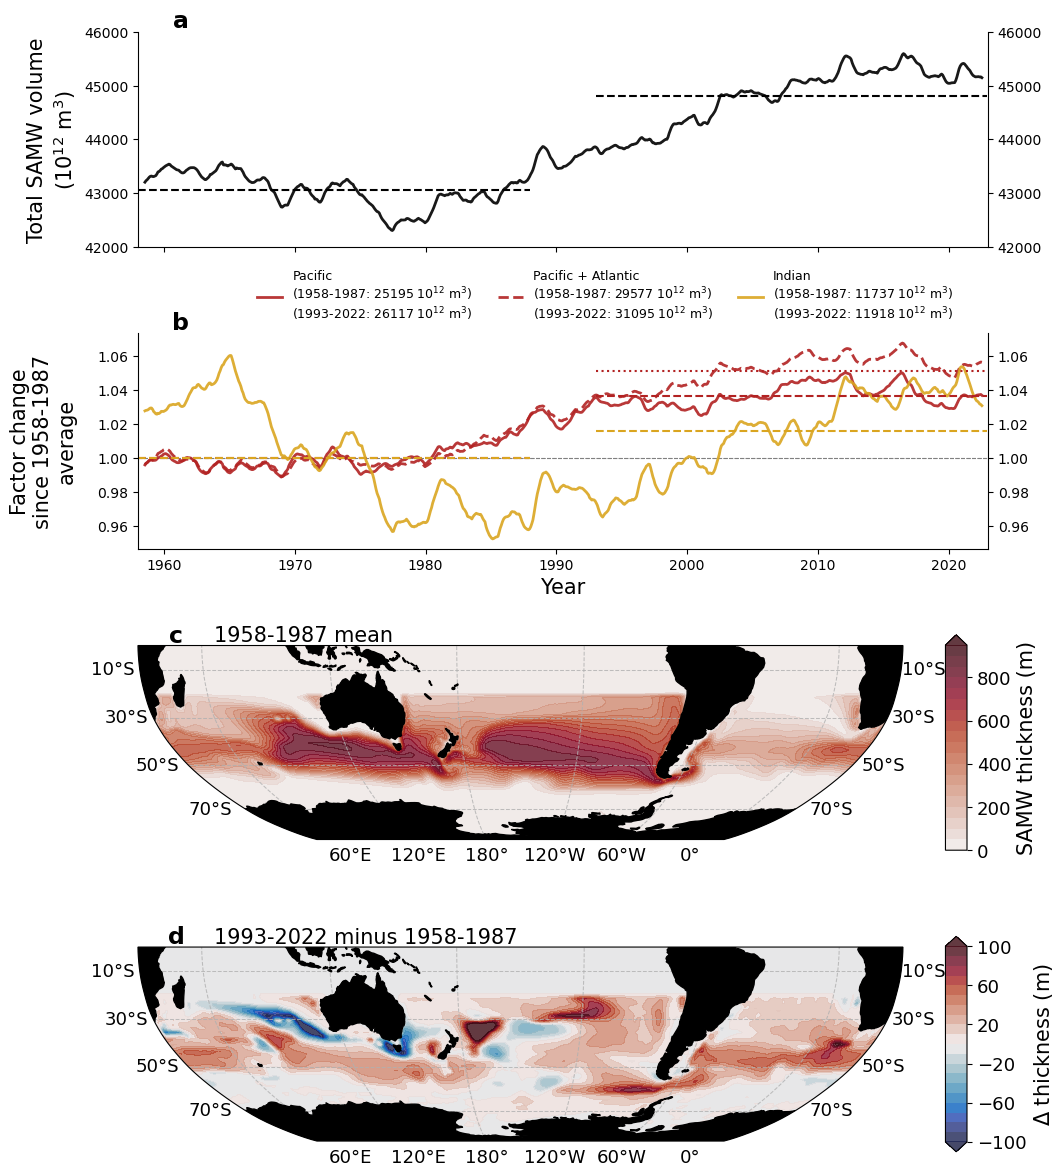

In [31]:

proj = ccrs.Robinson(central_longitude=210)

levs1 = np.arange(0,81,8)
levs2 = np.arange(-10,11,1)
levs9 = np.arange(0,21,2)
levs10 = np.arange(-5,5.1,0.5)

colmap1 = lighten(cmo.amp, 0.8)
colmap2 = lighten(cmo.balance, 0.8)
fstic = 13
fslab = 15

fig = plt.figure(figsize=(10,14), facecolor='w')
gs = GridSpec(4,1)

ax7 = plt.subplot(gs[0,0])
ax8 = plt.subplot(gs[1,0])
ax9 = plt.subplot(gs[2,0], projection=proj)
ax10 = plt.subplot(gs[3,0], projection=proj)

ax9.add_feature(cfeature.LAND, zorder=3, color='k')
ax10.add_feature(cfeature.LAND, zorder=3, color='k')
ax9.set_extent([-180,180,-90,0], crs=ccrs.PlateCarree())
ax10.set_extent([-180,180,-90,0], crs=ccrs.PlateCarree())

ax7.tick_params(right=True, labelbottom=False, labelright=True)
ax8.tick_params(right=True, labelright=True)

ax7.spines[['top']].set_visible(False)
ax8.spines[['top']].set_visible(False)

depths = depth_thicknesses.coords['depth']
lats_reg = ds_out['lat'].isel(x=0)

lwid = [1.0, 2.0, 2.0, 2.0]
cols = ['k', 'k']
lsty = ['-', '-']
alfs = 0.9

#ax7.plot(time, samw_volume_sum, color=cols[0], linewidth=lwid[0], alpha=alfs, linestyle=lsty[0])
ax7.plot(time, samw_volume_sum.rolling(time=12, center=True).mean(), color=cols[1], linewidth=lwid[1], alpha=alfs, linestyle=lsty[1])
ax7.plot(time[0:360], np.ones((360))*samw_volume_sum.isel(time=slice(0,360)).mean(dim='time').values, 'k--')
ax7.plot(time[-360::], np.ones((360))*samw_volume_sum.isel(time=slice(-360,780)).mean(dim='time').values, 'k--')

samw_volume_pac_per = (samw_volume_pac_sum / samw_volume_pac_sum.isel(time=slice(0,360)).mean(dim="time"))
samw_volume_ind_per = (samw_volume_ind_sum / samw_volume_ind_sum.isel(time=slice(0,360)).mean(dim="time"))
samw_volume_pacatl_per = ((samw_volume_atl_sum + samw_volume_pac_sum) / (samw_volume_atl_sum + samw_volume_pac_sum).isel(time=slice(0,360)).mean(dim="time"))


cols = ['firebrick', 'goldenrod', 'royalblue']
lab = ['Pacific\n(1958-1987: %d 10$^{12}$ m$^{3}$)\n(1993-2022: %d 10$^{12}$ m$^{3}$)'%(samw_volume_pac_sum.isel(time=slice(0,360)).mean(dim='time'), samw_volume_pac_sum.isel(time=slice(-360,-1)).mean(dim='time')), \
       'Indian\n(1958-1987: %d 10$^{12}$ m$^{3}$)\n(1993-2022: %d 10$^{12}$ m$^{3}$)'%(samw_volume_ind_sum.isel(time=slice(0,360)).mean(dim='time'), samw_volume_ind_sum.isel(time=slice(-360,-1)).mean(dim='time')), \
       'Pacific + Atlantic\n(1958-1987: %d 10$^{12}$ m$^{3}$)\n(1993-2022: %d 10$^{12}$ m$^{3}$)'%((samw_volume_atl_sum + samw_volume_pac_sum).isel(time=slice(0,360)).mean(dim='time'), (samw_volume_atl_sum + samw_volume_pac_sum).isel(time=slice(-360,-1)).mean(dim='time'))]

#ax8.plot(time, samw_volume_pac_per, color=cols[0], linewidth=lwid[0], alpha=alfs, linestyle=lsty[0])
#ax8.plot(time, samw_volume_pacatl_per, color=cols[0], linewidth=lwid[0], alpha=alfs, linestyle="--")
#ax8.plot(time, samw_volume_ind_per, color=cols[1], linewidth=lwid[0], alpha=alfs, linestyle=lsty[0])

ax8.plot(time, np.ones(len(time))*samw_volume_pac_per.isel(time=slice(0,360)).mean(dim='time').values, color='grey', linewidth=0.75, alpha=1.0, linestyle='--')
ax8.plot(time, np.ones(len(time))*samw_volume_pacatl_per.isel(time=slice(0,360)).mean(dim='time').values, color='grey', linewidth=0.75, alpha=1.0, linestyle='--')
ax8.plot(time, np.ones(len(time))*samw_volume_ind_per.isel(time=slice(0,360)).mean(dim='time').values, color='grey', linewidth=0.75, alpha=1.0, linestyle='--')

ax8.plot(time, samw_volume_pac_per.rolling(time=12, center=True).mean(), color=cols[0], linewidth=lwid[1], alpha=alfs, linestyle=lsty[1], label=lab[0])
ax8.plot(time, samw_volume_pacatl_per.rolling(time=12, center=True).mean(), color=cols[0], linewidth=lwid[1], alpha=alfs, linestyle="--", label=lab[2])
ax8.plot(time, samw_volume_ind_per.rolling(time=12, center=True).mean(), color=cols[1], linewidth=lwid[1], alpha=alfs, linestyle=lsty[1], label=lab[1])

ax8.plot(time[0:360], np.ones((360))*samw_volume_pac_per.isel(time=slice(0,360)).mean(dim='time').values, linestyle='--', color=cols[0])
ax8.plot(time[-360::], np.ones((360))*samw_volume_pac_per.isel(time=slice(-360,780)).mean(dim='time').values, linestyle='--', color=cols[0])
ax8.plot(time[0:360], np.ones((360))*samw_volume_ind_per.isel(time=slice(0,360)).mean(dim='time').values, linestyle='--', color=cols[1])
ax8.plot(time[-360::], np.ones((360))*samw_volume_ind_per.isel(time=slice(-360,780)).mean(dim='time').values, linestyle='--', color=cols[1])
ax8.plot(time[-360::], np.ones((360))*samw_volume_pacatl_per.isel(time=slice(-360,780)).mean(dim='time').values, linestyle=':', color=cols[0])


levs9 = np.arange(0,1000,50)
levs10 = np.arange(-100,101,10)

p9 = ax9.contourf(lon_reg_wrapped, ds_out['lat'].isel(x=0), samw_thick_start30_reg_wrapped, transform=ccrs.PlateCarree(), levels=levs9, cmap=colmap1, vmin=np.min(levs9), vmax=np.max(levs9), extend='max')
p10 = ax10.contourf(lon_reg_wrapped, ds_out['lat'].isel(x=0), (samw_thick_end30_reg_wrapped - samw_thick_start30_reg_wrapped), transform=ccrs.PlateCarree(), levels=levs10, cmap=colmap2, vmin=np.min(levs10), vmax=np.max(levs10), extend='both')

ax7.set_xlim(start_date,end_date)
ax8.set_xlim(start_date,end_date)
ax7.set_ylim(42000,46000)

ax8.set_xlabel("Year", fontsize=fslab)
ax7.set_ylabel("Total SAMW volume\n(10$^{12}$ m$^{3}$)", fontsize=fslab)
ax8.set_ylabel("Factor change\nsince 1958-1987\naverage", fontsize=fslab, labelpad=15)
ax8.legend(loc='upper center', frameon=False, fontsize=fstic-4, ncol=3, bbox_to_anchor=(0.55,1.35))

cbar9 = plt.colorbar(p9, ax=ax9, orientation='vertical', ticks=levs9[::4], fraction=0.05, aspect=10, pad=0.05)
cbar10 = plt.colorbar(p10, ax=ax10, orientation='vertical', ticks=levs10[::4], fraction=0.05, aspect=10, pad=0.05)
cbar9.ax.set_ylabel("SAMW thickness (m)", fontsize=fslab)
cbar10.ax.set_ylabel("$\Delta$ thickness (m)", fontsize=fslab)
cbar9.ax.tick_params(labelsize=fstic)
cbar10.ax.tick_params(labelsize=fstic)

plt.subplots_adjust(left=0.05, top=0.9, bottom=0.1, hspace=0.4)


xx = 0.05; yy = 1.05
plt.text(xx,yy,'a', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax7.transAxes)
plt.text(xx,yy,'b', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax8.transAxes)
plt.text(xx,yy,'c', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax9.transAxes)
plt.text(xx,yy,'d', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax10.transAxes)

xx = 0.05; yy = 1.05
plt.text(xx*2,yy,"1958-1987 mean", fontsize=fslab, va='center', ha='left', transform=ax9.transAxes)
plt.text(xx*2,yy,"1993-2022 minus 1958-1987", fontsize=fslab, va='center', ha='left', transform=ax10.transAxes)

import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

for ax in [ax9, ax10]:
    gl = ax.gridlines(
         crs=ccrs.PlateCarree(),
         draw_labels=True,
         linewidth=0.75,
         linestyle="--",
         alpha=0.8,
         x_inline=False,
         y_inline=False,
    )

    gl.xlocator = mticker.FixedLocator(
        [-180, -120, -60, 0, 60, 120]
    )
    gl.ylocator = mticker.FixedLocator(
        [-70, -50, -30, -10]
    )

    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()

    gl.top_labels = False
    gl.right_labels = True
    gl.left_labels = True
    gl.bottom_labels = True

    gl.xlabel_style = {"size": fstic}
    gl.ylabel_style = {"size": fstic}

In [43]:
fig.savefig('/home/pbuchanan/analysis_samw/fig-samw_cub_change_30years.png', dpi=300, bbox_inches='tight')
fig.savefig('/home/pbuchanan/analysis_samw/fig-samw_cub_change_30years.pdf', dpi=300, bbox_inches='tight')
fig.savefig('/home/pbuchanan/analysis_samw/fig-samw_cub_change_30years_trans.png', dpi=300, bbox_inches='tight', transparent=True)


## Check the change over the Argo period (since 2005) and compare with observations

In [32]:
os.getcwd()

'/expanse/lustre/projects/ciw112/pbuchanan/JRA55'

In [33]:
%%time

en4_samw_cub = xr.open_dataset("EN4_SAMWvol_cubic.nc")
en4_samw_cub


CPU times: user 7.69 ms, sys: 4.2 ms, total: 11.9 ms
Wall time: 178 ms


<xarray.Dataset> Size: 5GB
Dimensions:  (lat: 74, lon: 360, time: 216, depth: 100)
Coordinates:
  * lat      (lat) float32 296B -83.0 -82.0 -81.0 -80.0 ... -12.0 -11.0 -10.0
  * lon      (lon) float32 1kB 1.0 2.0 3.0 4.0 5.0 ... 357.0 358.0 359.0 360.0
  * time     (time) datetime64[ns] 2kB 2005-01-16T12:00:00 ... 2022-12-16T12:...
  * depth    (depth) int64 800B 5 25 45 65 85 105 ... 1905 1925 1945 1965 1985
Data variables:
    SAMWvol  (time, depth, lat, lon) float64 5GB ...

### calculate dx and dy in metres on the obs grid

In [48]:
%%time

# Earth’s radius in meters
R = 6_371_000  

# 1) Determine grid spacing in degrees
dlat = float(en4_samw_cub.lat[1] - en4_samw_cub.lat[0])  # assuming uniform lat spacing
dlon = float(en4_samw_cub.lon[1] - en4_samw_cub.lon[0])  # assuming uniform lon spacing

# 2) Convert degrees to radians
dlat_rad = np.deg2rad(dlat)
dlon_rad = np.deg2rad(dlon)

# 3) For small cells on a sphere, area ≈ R^2 * dlat * dlon * cos(lat)
lat_rad = np.deg2rad(en4_samw_cub.lat)

# Meridional grid-cell length: constant with latitude
en4_dy = xr.full_like(en4_samw_cub.lat, R * dlat_rad, dtype=float)

# Zonal grid-cell length: varies with latitude
en4_dx = R * np.cos(lat_rad) * dlon_rad

# cell_area will be 1D in 'lat' but we expand along 'lon' so it matches ds' shape
cell_area_1d = R**2 * dlat_rad * dlon_rad * np.cos(lat_rad)
cell_area = cell_area_1d.broadcast_like(en4_samw_cub.lon)  # shape => (lat, lon)

# 4) Attach as a new DataArray in the dataset
en4_samw_cub['cell_area'] = cell_area
en4_samw_cub['cell_area'].attrs = {
    'units': 'm^2',
    'description': 'Approximate area of each lat/lon grid cell'
}

en4_samw_cub


CPU times: user 3.85 ms, sys: 0 ns, total: 3.85 ms
Wall time: 3.86 ms


<xarray.Dataset> Size: 14GB
Dimensions:    (lat: 74, lon: 360, time: 216, depth: 100)
Coordinates:
  * lat        (lat) float32 296B -83.0 -82.0 -81.0 -80.0 ... -12.0 -11.0 -10.0
  * lon        (lon) float32 1kB 1.0 2.0 3.0 4.0 5.0 ... 357.0 358.0 359.0 360.0
  * time       (time) datetime64[ns] 2kB 2005-01-16T12:00:00 ... 2022-12-16T1...
  * depth      (depth) int64 800B 5 25 45 65 85 105 ... 1905 1925 1945 1965 1985
Data variables:
    SAMWvol    (time, depth, lat, lon) float64 5GB ...
    cell_area  (lon, lat) float32 107kB 1.507e+09 1.721e+09 ... 1.218e+10
    SAMWthick  (time, depth, lat, lon) float64 5GB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SAMW       (time, depth, lat, lon) float64 5GB 0.0 0.0 0.0 ... 0.0 0.0 0.0

### calculate the EN4 observational SAMW thickness

In [49]:
%%time

en4_samw_cub['SAMW'] = en4_samw_cub['SAMWvol'] / en4_samw_cub['cell_area'] / depth_thicknesses
en4_samw_cub


CPU times: user 1.01 s, sys: 1.44 s, total: 2.46 s
Wall time: 2.46 s


<xarray.Dataset> Size: 14GB
Dimensions:    (lat: 74, lon: 360, time: 216, depth: 100)
Coordinates:
  * lat        (lat) float32 296B -83.0 -82.0 -81.0 -80.0 ... -12.0 -11.0 -10.0
  * lon        (lon) float32 1kB 1.0 2.0 3.0 4.0 5.0 ... 357.0 358.0 359.0 360.0
  * time       (time) datetime64[ns] 2kB 2005-01-16T12:00:00 ... 2022-12-16T1...
  * depth      (depth) int64 800B 5 25 45 65 85 105 ... 1905 1925 1945 1965 1985
Data variables:
    SAMWvol    (time, depth, lat, lon) float64 5GB ...
    cell_area  (lon, lat) float32 107kB 1.507e+09 1.721e+09 ... 1.218e+10
    SAMWthick  (time, depth, lat, lon) float64 5GB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SAMW       (time, depth, lat, lon) float64 5GB 0.0 0.0 0.0 ... 0.0 0.0 0.0

CPU times: user 24.8 ms, sys: 1.97 ms, total: 26.7 ms
Wall time: 25.9 ms


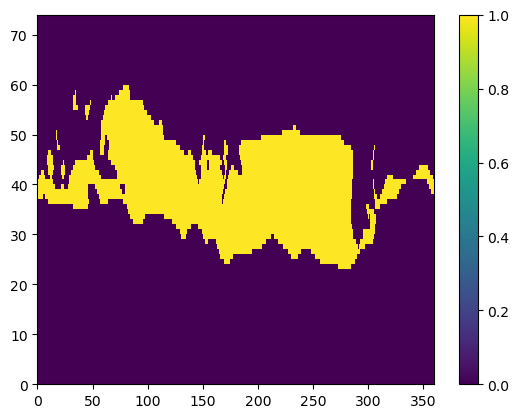

In [44]:
%%time

plt.figure()
plt.pcolormesh(en4_samw_cub['SAMW'].isel(depth=20,time=1))
plt.colorbar()


In [82]:
%%time

# mean over start and end 5 years
en4_samw_startARGO = en4_samw_cub['SAMW'].sel(time=slice("2005-01-01","2009-12-31")).mean(dim='time')
en4_samw_endARGO = en4_samw_cub['SAMW'].sel(time=slice("2018-01-01","2022-12-31")).mean(dim='time')

# sum in depth space to get thicknesses
en4_samw_thick_startARGO = (en4_samw_startARGO * depth_thicknesses).sum(dim='depth')
en4_samw_thick_endARGO = (en4_samw_endARGO * depth_thicknesses).sum(dim='depth')

# sum in the zonal dimension to get basin side thicknesses
en4_samw_side_startARGO = (en4_samw_startARGO * en4_dx)
en4_samw_side_endARGO = (en4_samw_endARGO * en4_dx)

# separate into basins
lons_tmp = en4_samw_side_startARGO.coords['lon']
lons_tmp = lons_tmp.where(lons_tmp >0.0, other=lons_tmp+360.0)
tmp = en4_samw_side_startARGO.assign_coords({"lon":lons_tmp})
en4_samw_pacside_startARGO = tmp.where(tmp.coords['lon'] > 140.0, other=0.0).where(tmp.coords['lon'] < 270.0, other=0.0).sum(dim='lon')
tmp = en4_samw_side_endARGO.assign_coords({"lon":lons_tmp})
en4_samw_pacside_endARGO = tmp.where(tmp.coords['lon'] > 140.0, other=0.0).where(tmp.coords['lon'] < 270.0, other=0.0).sum(dim='lon')
en4_samw_indside_startARGO = en4_samw_side_startARGO.sel(lon=slice(40,140)).sum(dim='lon')
en4_samw_indside_endARGO = en4_samw_side_endARGO.sel(lon=slice(40,140)).sum(dim='lon')



CPU times: user 891 ms, sys: 203 ms, total: 1.09 s
Wall time: 1.1 s


In [83]:
%%time

### wrap the longitudes for the top-down vertical thicknesses
en4_samw_thick_startARGO = xr.DataArray(
    en4_samw_thick_startARGO,
    dims=("y", "x"),
    coords={"lon": (['x'], en4_samw_startARGO.coords['lon'].values),
            "lat": (['y'], en4_samw_startARGO.coords['lat'].values),
            }
    )
en4_samw_thick_endARGO = xr.DataArray(
    en4_samw_thick_endARGO,
    dims=("y", "x"),
    coords={"lon": (['x'], en4_samw_startARGO.coords['lon'].values),
            "lat": (['y'], en4_samw_startARGO.coords['lat'].values),
            }
    )

en4_samw_thick_startARGO_wrapped, en4_lon_wrapped = cutil.add_cyclic_point(en4_samw_thick_startARGO, coord=en4_samw_thick_startARGO.coords['lon'])
en4_samw_thick_endARGO_wrapped, en4_lon_wrapped = cutil.add_cyclic_point(en4_samw_thick_endARGO, coord=en4_samw_thick_endARGO.coords['lon'])




CPU times: user 1.98 ms, sys: 25 μs, total: 2.01 ms
Wall time: 1.87 ms


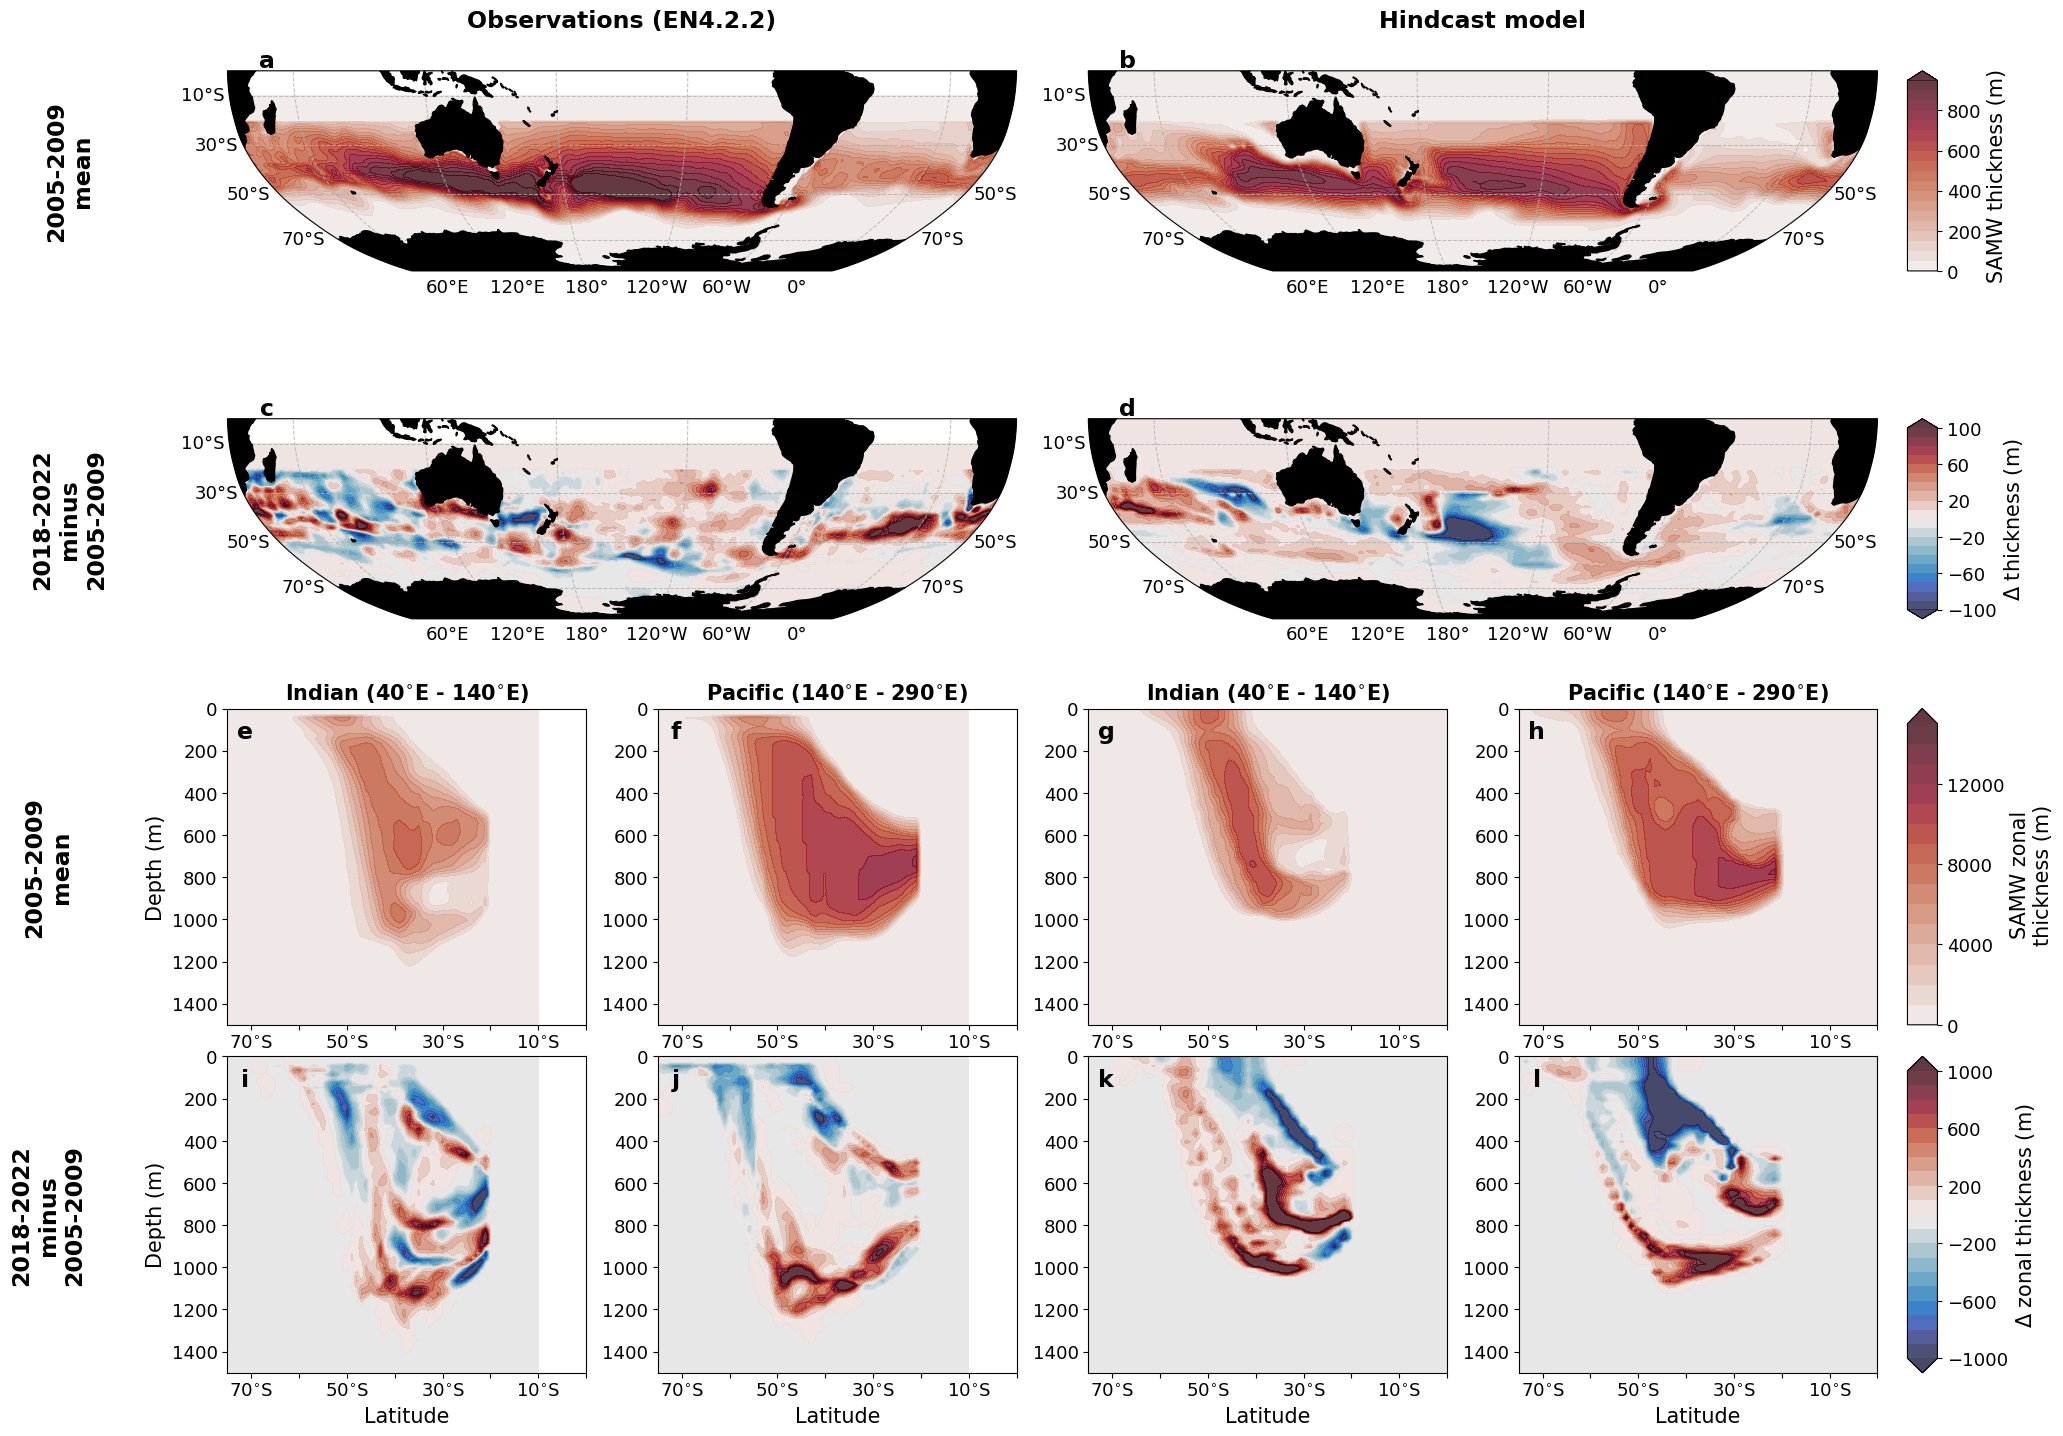

In [92]:

proj = ccrs.Robinson(central_longitude=210)

levs1 = np.arange(0,1000,50)
levs2 = np.arange(-100,101,10)
levs3 = np.arange(0,15001,1000)
levs4 = np.arange(-1000,1001,100)

colmap1 = lighten(cmo.amp, 0.8)
colmap2 = lighten(cmo.balance, 0.8)
fstic = 13
fslab = 15

fig = plt.figure(figsize=(20,16), facecolor='w')
gs = GridSpec(4,4)

ax1 = plt.subplot(gs[0,0:2], projection=proj)
ax2 = plt.subplot(gs[0,2:4], projection=proj)
ax3 = plt.subplot(gs[1,0:2], projection=proj)
ax4 = plt.subplot(gs[1,2:4], projection=proj)
ax5 = plt.subplot(gs[2,0])
ax6 = plt.subplot(gs[2,1])
ax7 = plt.subplot(gs[2,2])
ax8 = plt.subplot(gs[2,3])
ax9 = plt.subplot(gs[3,0])
ax10 = plt.subplot(gs[3,1])
ax11 = plt.subplot(gs[3,2])
ax12 = plt.subplot(gs[3,3])

ax1.add_feature(cfeature.LAND, zorder=3, color='k')
ax2.add_feature(cfeature.LAND, zorder=3, color='k')
ax3.add_feature(cfeature.LAND, zorder=3, color='k')
ax4.add_feature(cfeature.LAND, zorder=3, color='k')
ax1.set_extent([-180,180,-90,0], crs=ccrs.PlateCarree())
ax2.set_extent([-180,180,-90,0], crs=ccrs.PlateCarree())
ax3.set_extent([-180,180,-90,0], crs=ccrs.PlateCarree())
ax4.set_extent([-180,180,-90,0], crs=ccrs.PlateCarree())

axs = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10, ax11, ax12]
for ax in axs:
    ax.tick_params(labelsize=fstic)

p1 = ax1.contourf(en4_lon_wrapped, en4_samw_startARGO['lat'], 
                  en4_samw_thick_startARGO_wrapped, 
                  transform=ccrs.PlateCarree(), levels=levs1, cmap=colmap1, vmin=np.min(levs1), vmax=np.max(levs1), extend='max')
p3 = ax3.contourf(en4_lon_wrapped, en4_samw_startARGO['lat'], 
                  (en4_samw_thick_endARGO_wrapped - en4_samw_thick_startARGO_wrapped)+0.01, 
                  transform=ccrs.PlateCarree(), levels=levs2, cmap=colmap2, vmin=np.min(levs2), vmax=np.max(levs2), extend='both')

p2 = ax2.contourf(lon_reg_wrapped, ds_out['lat'].isel(x=0), 
                  samw_thick_startARGO_reg_wrapped, 
                  transform=ccrs.PlateCarree(), levels=levs1, cmap=colmap1, vmin=np.min(levs1), vmax=np.max(levs1), extend='max')
p4 = ax4.contourf(lon_reg_wrapped, ds_out['lat'].isel(x=0), 
                  (samw_thick_endARGO_reg_wrapped - samw_thick_startARGO_reg_wrapped)+0.01, 
                  transform=ccrs.PlateCarree(), levels=levs2, cmap=colmap2, vmin=np.min(levs2), vmax=np.max(levs2), extend='both')

depths = en4_samw_indside_startARGO.coords['depth']
lats_reg = en4_samw_startARGO['lat']
p5 = ax5.contourf(lats_reg, depths, en4_samw_indside_startARGO * 1e-3, 
                  levels=levs3, cmap=colmap1, vmin=np.min(levs3), vmax=np.max(levs3), extend='max')
p6 = ax6.contourf(lats_reg, depths, en4_samw_pacside_startARGO * 1e-3, 
                  levels=levs3, cmap=colmap1, vmin=np.min(levs3), vmax=np.max(levs3), extend='max')
p9 = ax9.contourf(lats_reg, depths, (en4_samw_indside_endARGO - en4_samw_indside_startARGO) * 1e-3, 
                    levels=levs4, cmap=colmap2, vmin=np.min(levs4), vmax=np.max(levs4), extend='both')
p10 = ax10.contourf(lats_reg, depths, (en4_samw_pacside_endARGO - en4_samw_pacside_startARGO) * 1e-3, 
                    levels=levs4, cmap=colmap2, vmin=np.min(levs4), vmax=np.max(levs4), extend='both')

depths = samw_indside_startARGO_reg.coords['depth']
lats_reg = ds_out['lat'].isel(x=0)
p7 = ax7.contourf(lats_reg, depths, samw_indside_startARGO_reg * 1e-3, 
                  levels=levs3, cmap=colmap1, vmin=np.min(levs3), vmax=np.max(levs3), extend='max')
p8 = ax8.contourf(lats_reg, depths, samw_pacside_startARGO_reg * 1e-3, 
                  levels=levs3, cmap=colmap1, vmin=np.min(levs3), vmax=np.max(levs3), extend='max')
p11 = ax11.contourf(lats_reg, depths, (samw_indside_endARGO_reg - samw_indside_startARGO_reg) * 1e-3, 
                    levels=levs4, cmap=colmap2, vmin=np.min(levs4), vmax=np.max(levs4), extend='both')
p12 = ax12.contourf(lats_reg, depths, (samw_pacside_endARGO_reg - samw_pacside_startARGO_reg) * 1e-3, 
                    levels=levs4, cmap=colmap2, vmin=np.min(levs4), vmax=np.max(levs4), extend='both')


x1 = -75; x2 = 0
y1 = 1500; y2 = 0
axs = [ax5, ax6, ax7, ax8, ax9, ax10, ax11, ax12]
for ax in axs:
    ax.set_xlim(x1,x2); ax.set_ylim(y1,y2)

x1 = np.arange(-70,1,10); x2 = np.array(["70$^{\circ}$S", " ", "50$^{\circ}$S", " ", "30$^{\circ}$S", " ", "10$^{\circ}$S", " " ])
y1 = np.arange(1400,-1,-200); y2 = np.arange(1400,-1,-200)
axs = [ax5, ax6, ax7, ax8, ax9, ax10, ax11, ax12]
for ax in axs:
    ax.set_xticks(x1,x2, fontsize=fstic); ax.set_yticks(y1,y2, fontsize=fstic)

xx = 0.5; yy = 1.05
plt.text(xx,yy+0.2,'Observations (EN4.2.2)', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax1.transAxes)
plt.text(xx,yy+0.2,'Hindcast model', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax2.transAxes)
plt.text(xx,yy,'Indian (40$^{\circ}$E - 140$^{\circ}$E)', fontsize=fslab, va='center', ha='center', fontweight='bold', transform=ax5.transAxes)
plt.text(xx,yy,'Pacific (140$^{\circ}$E - 290$^{\circ}$E)', fontsize=fslab, va='center', ha='center', fontweight='bold', transform=ax6.transAxes)
plt.text(xx,yy,'Indian (40$^{\circ}$E - 140$^{\circ}$E)', fontsize=fslab, va='center', ha='center', fontweight='bold', transform=ax7.transAxes)
plt.text(xx,yy,'Pacific (140$^{\circ}$E - 290$^{\circ}$E)', fontsize=fslab, va='center', ha='center', fontweight='bold', transform=ax8.transAxes)

ax5.set_ylabel("Depth (m)", fontsize=fslab)
ax9.set_ylabel("Depth (m)", fontsize=fslab)
ax9.set_xlabel("Latitude", fontsize=fslab)
ax10.set_xlabel("Latitude", fontsize=fslab)
ax11.set_xlabel("Latitude", fontsize=fslab)
ax12.set_xlabel("Latitude", fontsize=fslab)

plt.subplots_adjust(left=0.05, top=0.90, bottom=0.05, hspace=0.1, right=0.875)


ax2pos = ax2.get_position()
ax4pos = ax4.get_position()
ax8pos = ax8.get_position()
ax12pos = ax12.get_position()

cbax2 = fig.add_axes([ax2pos.x1 + 0.015, ax2pos.y0, 0.015, ax2pos.y1 - ax2pos.y0])
cbax4 = fig.add_axes([ax4pos.x1 + 0.015, ax4pos.y0, 0.015, ax4pos.y1 - ax4pos.y0])
cbax8 = fig.add_axes([ax8pos.x1 + 0.015, ax8pos.y0, 0.015, ax8pos.y1 - ax8pos.y0])
cbax12 = fig.add_axes([ax12pos.x1 + 0.015, ax12pos.y0, 0.015, ax12pos.y1 - ax12pos.y0])

cbar2 = plt.colorbar(p2, cax=cbax2, orientation='vertical', ticks=levs1[::4])
cbar4 = plt.colorbar(p4, cax=cbax4, orientation='vertical', ticks=levs2[::4])
cbar8 = plt.colorbar(p8, cax=cbax8, orientation='vertical', ticks=levs3[::4])
cbar12 = plt.colorbar(p12, cax=cbax12, orientation='vertical', ticks=levs4[::4])

cbar2.ax.set_ylabel("SAMW thickness (m)", fontsize=fslab)
cbar4.ax.set_ylabel("$\Delta$ thickness (m)", fontsize=fslab)
cbar8.ax.set_ylabel("SAMW zonal\nthickness (m)", fontsize=fslab)
cbar12.ax.set_ylabel("$\Delta$ zonal thickness (m)", fontsize=fslab)

cbar2.ax.tick_params(labelsize=fstic)
cbar4.ax.tick_params(labelsize=fstic)
cbar8.ax.tick_params(labelsize=fstic)
cbar12.ax.tick_params(labelsize=fstic)

lets = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l']
axs = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10, ax11, ax12]
for i,ax in enumerate(axs):
    if i < 4:
        xx = 0.05; yy = 1.05
    else:
        xx = 0.05; yy = 0.925
    plt.text(xx,yy,lets[i], fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax.transAxes)

xx = -0.2; yy = 0.5
plt.text(xx,yy,"2005-2009\nmean", fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax1.transAxes, rotation=90)
plt.text(xx,yy,"2018-2022\nminus\n2005-2009", fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax3.transAxes, rotation=90)
plt.text(xx*2.5,yy,"2005-2009\nmean", fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax5.transAxes, rotation=90)
plt.text(xx*2.5,yy,"2018-2022\nminus\n2005-2009", fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax9.transAxes, rotation=90)

import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

for ax in [ax1, ax2, ax3, ax4]:
    gl = ax.gridlines(
         crs=ccrs.PlateCarree(),
         draw_labels=True,
         linewidth=0.75,
         linestyle="--",
         alpha=0.8,
         x_inline=False,
         y_inline=False,
    )

    gl.xlocator = mticker.FixedLocator(
        [-180, -120, -60, 0, 60, 120]
    )
    gl.ylocator = mticker.FixedLocator(
        [-70, -50, -30, -10]
    )

    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()

    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = True
    gl.bottom_labels = True

    gl.xlabel_style = {"size": fstic}
    gl.ylabel_style = {"size": fstic}


In [93]:
fig.savefig('/home/pbuchanan/analysis_samw/fig-samw_cub_change_2005-2022.png', dpi=300, bbox_inches='tight')
fig.savefig('/home/pbuchanan/analysis_samw/fig-samw_cub_change_2005-2022.pdf', dpi=300, bbox_inches='tight')
fig.savefig('/home/pbuchanan/analysis_samw/fig-samw_cub_change_2005-2022_trans.png', dpi=300, bbox_inches='tight', transparent=True)


### Linear interpolation (Basins)

In [ ]:
%%time

### do the same for the basin-specific waters
samw_lin_volume_pac = samw_lin_volume_pac.transpose("time", "depth", "y", "x")
samw_lin_volume_atl = samw_lin_volume_atl.transpose("time", "depth", "y", "x")
samw_lin_volume_ind = samw_lin_volume_ind.transpose("time", "depth", "y", "x")
aaiw_lin_volume_pac = aaiw_lin_volume_pac.transpose("time", "depth", "y", "x")
aaiw_lin_volume_atl = aaiw_lin_volume_atl.transpose("time", "depth", "y", "x")
aaiw_lin_volume_ind = aaiw_lin_volume_ind.transpose("time", "depth", "y", "x")

### PACIFIC ###
print("Regridding Pacific")
ds_in = xr.Dataset(
    {'samw_lin_volume_pac': ( ('time', 'depth', 'y', 'x'), samw_lin_volume_pac.values),
     'aaiw_lin_volume_pac': ( ('time', 'depth', 'y', 'x'), aaiw_lin_volume_pac.values),
      },
    coords={"lon": (['y','x'], samw_lin_volume_pac.coords['lon'].values),
            "lat": (['y','x'], samw_lin_volume_pac.coords['lat'].values),
            "depth": (['depth'], samw_lin_volume_pac.coords['depth'].values),
            "time": (['time'], samw_lin_volume_pac.coords['time'].values),
            }
    )
regridder = xe.Regridder(ds_in, ds_out, 'bilinear', ignore_degenerate=True)
samw_lin_volume_pac_reg = regridder(ds_in['samw_lin_volume_pac'])
aaiw_lin_volume_pac_reg = regridder(ds_in['aaiw_lin_volume_pac'])

### INDIAN ###
print("Regridding Indian")
ds_in = xr.Dataset(
    {'samw_lin_volume_ind': ( ('time', 'depth', 'y', 'x'), samw_lin_volume_ind.values),
     'aaiw_lin_volume_ind': ( ('time', 'depth', 'y', 'x'), aaiw_lin_volume_ind.values),
      },
    coords={"lon": (['y','x'], samw_lin_volume_ind.coords['lon'].values),
            "lat": (['y','x'], samw_lin_volume_ind.coords['lat'].values),
            "depth": (['depth'], samw_lin_volume_ind.coords['depth'].values),
            "time": (['time'], samw_lin_volume_ind.coords['time'].values),
            }
    )
regridder = xe.Regridder(ds_in, ds_out, 'bilinear', ignore_degenerate=True)
samw_lin_volume_ind_reg = regridder(ds_in['samw_lin_volume_ind'])
aaiw_lin_volume_ind_reg = regridder(ds_in['aaiw_lin_volume_ind'])

### ATLANTIC ###
print("Regridding Atlantic")
ds_in = xr.Dataset(
    {'samw_lin_volume_atl': ( ('time', 'depth', 'y', 'x'), samw_lin_volume_atl.values),
     'aaiw_lin_volume_atl': ( ('time', 'depth', 'y', 'x'), aaiw_lin_volume_atl.values),
      },
    coords={"lon": (['y','x'], samw_lin_volume_atl.coords['lon'].values),
            "lat": (['y','x'], samw_lin_volume_atl.coords['lat'].values),
            "depth": (['depth'], samw_lin_volume_atl.coords['depth'].values),
            "time": (['time'], samw_lin_volume_atl.coords['time'].values),
            }
    )
regridder = xe.Regridder(ds_in, ds_out, 'bilinear', ignore_degenerate=True)
samw_lin_volume_atl_reg = regridder(ds_in['samw_lin_volume_atl'])
aaiw_lin_volume_atl_reg = regridder(ds_in['aaiw_lin_volume_atl'])


### Cubic interpolation (Global)

In [ ]:
%%time

samw_cub_volume = samw_cub_volume.transpose("time", "depth", "y", "x")
aaiw_cub_volume = aaiw_cub_volume.transpose("time", "depth", "y", "x")
rho0_cub = rho0_cub.transpose("time", "depth", "y", "x")

ds_in = xr.Dataset(
    {'samw_cub_volume': ( ('time', 'depth', 'y', 'x'), samw_cub_volume.values),
     'aaiw_cub_volume': ( ('time', 'depth', 'y', 'x'), aaiw_cub_volume.values),
     'rho0_cub': ( ('time', 'depth', 'y', 'x'), rho0_cub.values),
     },
    coords={"lon": (['y','x'], lons.values),
            "lat": (['y','x'], lats.values),
            "depth": (['depth'], samw_lin_volume.coords['depth'].values),
            "time": (['time'], samw_lin_volume.coords['time'].values),
            }
    )
regridder = xe.Regridder(ds_in, ds_out, 'bilinear', ignore_degenerate=True)

samw_cub_volume_reg = regridder(ds_in['samw_cub_volume'])
aaiw_cub_volume_reg = regridder(ds_in['aaiw_cub_volume'])
rho0_cub_reg = regridder(ds_in['rho0_cub'])


### Cubic interpolation (Basins)

In [ ]:
%%time

samw_cub_volume_pac = samw_cub_volume_pac.transpose("time", "depth", "y", "x")
samw_cub_volume_atl = samw_cub_volume_atl.transpose("time", "depth", "y", "x")
samw_cub_volume_ind = samw_cub_volume_ind.transpose("time", "depth", "y", "x")
aaiw_cub_volume_pac = aaiw_cub_volume_pac.transpose("time", "depth", "y", "x")
aaiw_cub_volume_atl = aaiw_cub_volume_atl.transpose("time", "depth", "y", "x")
aaiw_cub_volume_ind = aaiw_cub_volume_ind.transpose("time", "depth", "y", "x")

### PACIFIC ###
ds_in = xr.Dataset(
    {'samw_cub_volume_pac': ( ('time', 'depth', 'y', 'x'), samw_cub_volume_pac.values),
     'aaiw_cub_volume_pac': ( ('time', 'depth', 'y', 'x'), aaiw_cub_volume_pac.values),
      },
    coords={"lon": (['y','x'], samw_lin_volume_pac.coords['lon'].values),
            "lat": (['y','x'], samw_lin_volume_pac.coords['lat'].values),
            "depth": (['depth'], samw_lin_volume_pac.coords['depth'].values),
            "time": (['time'], samw_lin_volume_pac.coords['time'].values),
            }
    )
regridder = xe.Regridder(ds_in, ds_out, 'bilinear', ignore_degenerate=True)
samw_cub_volume_pac_reg = regridder(ds_in['samw_cub_volume_pac'])
aaiw_cub_volume_pac_reg = regridder(ds_in['aaiw_cub_volume_pac'])

### INDIAN ###
ds_in = xr.Dataset(
    {'samw_cub_volume_ind': ( ('time', 'depth', 'y', 'x'), samw_cub_volume_ind.values),
     'aaiw_cub_volume_ind': ( ('time', 'depth', 'y', 'x'), aaiw_cub_volume_ind.values),
      },
    coords={"lon": (['y','x'], samw_lin_volume_ind.coords['lon'].values),
            "lat": (['y','x'], samw_lin_volume_ind.coords['lat'].values),
            "depth": (['depth'], samw_lin_volume_ind.coords['depth'].values),
            "time": (['time'], samw_lin_volume_ind.coords['time'].values),
            }
    )
regridder = xe.Regridder(ds_in, ds_out, 'bilinear', ignore_degenerate=True)
samw_cub_volume_ind_reg = regridder(ds_in['samw_cub_volume_ind'])
aaiw_cub_volume_ind_reg = regridder(ds_in['aaiw_cub_volume_ind'])

### ATLANTIC ###
ds_in = xr.Dataset(
    {'samw_cub_volume_atl': ( ('time', 'depth', 'y', 'x'), samw_cub_volume_atl.values),
     'aaiw_cub_volume_atl': ( ('time', 'depth', 'y', 'x'), aaiw_cub_volume_atl.values),
      },
    coords={"lon": (['y','x'], samw_lin_volume_atl.coords['lon'].values),
            "lat": (['y','x'], samw_lin_volume_atl.coords['lat'].values),
            "depth": (['depth'], samw_lin_volume_atl.coords['depth'].values),
            "time": (['time'], samw_lin_volume_atl.coords['time'].values),
            }
    )
regridder = xe.Regridder(ds_in, ds_out, 'bilinear', ignore_degenerate=True)
samw_cub_volume_atl_reg = regridder(ds_in['samw_cub_volume_atl'])
aaiw_cub_volume_atl_reg = regridder(ds_in['aaiw_cub_volume_atl'])

## what does the volume change look like from above for SAMW?

In [ ]:


lon_reg = ds_out.coords['lon']
lat_reg = ds_out.coords['lat']

proj = ccrs.Robinson(central_longitude=210)

levs1 = np.arange(0,21,2)
levs2 = np.arange(-5,5.1,0.5)
colmap1 = lighten(cmo.amp, 0.8)
colmap2 = lighten(cmo.balance, 0.8)
fstic = 13
fslab = 15

fig = plt.figure(figsize=(12,10), facecolor='w')
gs = GridSpec(2,1)

ax1 = plt.subplot(gs[0,0], projection=proj)
ax2 = plt.subplot(gs[1,0], projection=proj)

ax1.add_feature(cfeature.LAND, zorder=3, color='k')
#ax1.add_feature(cfeature.COASTLINE, zorder=3)
ax2.add_feature(cfeature.LAND, zorder=3, color='k')
#ax2.add_feature(cfeature.COASTLINE, zorder=3)
ax1.set_extent([-180,180,-90,0], crs=ccrs.PlateCarree())
ax2.set_extent([-180,180,-90,0], crs=ccrs.PlateCarree())
    
p1 = ax1.contourf(lon_reg,lat_reg, samw_volume_reg.isel(time=slice(0,240)).mean(dim='time').sum(dim='depth') * 1e-12, \
                  transform=ccrs.PlateCarree(), levels=levs1, cmap=colmap1, vmin=np.min(levs1), vmax=np.max(levs1), extend='max')
p2 = ax2.contourf(lon_reg,lat_reg, (samw_volume_reg.isel(time=slice(-240,780)).mean(dim='time').sum(dim='depth') - samw_volume_reg.isel(time=slice(0,240)).mean(dim='time').sum(dim='depth')) * 1e-12, \
                  transform=ccrs.PlateCarree(), levels=levs2, cmap=colmap2, vmin=np.min(levs2), vmax=np.max(levs2), extend='both')

cbar1 = plt.colorbar(p1, ax=ax1, orientation='horizontal', ticks=levs1[::4], fraction=0.075, aspect=20, pad=0.05)
cbar2 = plt.colorbar(p2, ax=ax2, orientation='horizontal', ticks=levs2[::4], fraction=0.075, aspect=20, pad=0.05)

cbar1.ax.set_xlabel("Volume of SAMW (10$^{12}$ m$^{-2}$)", fontsize=fslab)
cbar2.ax.set_xlabel("$\Delta$ Volume (10$^{12}$ m$^{-2}$)", fontsize=fslab)

cbar1.ax.tick_params(labelsize=fstic)
cbar2.ax.tick_params(labelsize=fstic)

plt.subplots_adjust(left=0.05, top=0.9, bottom=0.1, hspace=0.4)


xx = 0.05; yy = 1.05
ax1.text(xx,yy,'a', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax1.transAxes)
ax2.text(xx,yy,'b', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax2.transAxes)
ax1.text(xx*2,yy,"1958-1977 mean", fontsize=fslab, va='center', ha='left', transform=ax1.transAxes)
ax2.text(xx*2,yy,"2003-2022 minus 1958-1977", fontsize=fslab, va='center', ha='left', transform=ax2.transAxes)


In [ ]:
fig.savefig('/home/pbuchanan/analysis_samw/fig-samw_volume_areachange_20years.png', dpi=300, bbox_inches='tight')
fig.savefig('/home/pbuchanan/analysis_samw/fig-samw_volume_areachange_20years.pdf', dpi=300, bbox_inches='tight')
fig.savefig('/home/pbuchanan/analysis_samw/fig-samw_volume_areachange_20years_trans.png', dpi=300, bbox_inches='tight', transparent=True)

